https://colab.research.google.com/drive/1S9FLECHcfTFR4IIJXt6SxWA6ARtKMVY7#scrollTo=swn_mDeVv6gD

https://github.com/611noorsaeed/Fine-Tuning-DistilBERT-for-Intent-Detection-Conversation-Message-Classification-with-LLM/tree/main

https://www.kaggle.com/datasets/himanshunayal/intent-recognition-dataset

Dataset Intent Recognition Dataset trên Kaggle do tác giả Himanshu Nayal chia sẻ là một tập dữ liệu dạng văn bản (text dataset) được thiết kế đặc biệt cho các bài toán Nhận diện ý định (Intent Recognition) và Phân loại văn bản (Text Classification) trong Xử lý ngôn ngữ tự nhiên (NLP).

1. Mục đích của Dataset
Bài toán chính: Phân loại câu lệnh/tin nhắn của người dùng thành các ý định (intent) tương ứng. Đây là thành phần cốt lõi trong việc xây dựng các trợ lý ảo, chatbot thông minh, hệ thống tổng đài tự động (IVR) hoặc các giao diện điều khiển bằng giọng nói/văn bản.

Quy mô: Dataset chứa hơn 13.000 mẫu dữ liệu (samples) với đa dạng các nhãn ý định khác nhau, cung cấp lượng dữ liệu tương đối phong phú để huấn luyện các mô hình học máy (Machine Learning) hoặc học sâu (Deep Learning).

2. Cấu trúc dữ liệu thông thường
Các dataset dạng nhận diện ý định trong chatbot/NLU (Natural Language Understanding) thường có cấu trúc dạng bảng (CSV) hoặc JSON/TXT bao gồm 2 cột chính:

Text / Utterance: Câu nói, yêu cầu hoặc câu lệnh do người dùng nhập vào (Ví dụ: "What's the weather like today?", "Book a flight to New York").

Intent (Nhãn): Ý định tương ứng của câu nói đó (Ví dụ: GetWeather, BookFlight).

3. Các bước xử lý và ứng dụng thực tế
Nếu bạn muốn sử dụng dataset này trong các dự án của mình, quy trình xử lý tiêu chuẩn thường bao gồm:

Tiền xử lý văn bản (Text Preprocessing):

Chuyển đổi văn bản về chữ thường (lowercase).

Loại bỏ các ký tự đặc biệt, dấu câu thừa.

Tokenization (tách từ) hoặc lemmatization tùy thuộc vào mô hình bạn chọn.

Trích xuất đặc trưng (Feature Extraction):

Sử dụng các phương pháp truyền thống như TF-IDF, Bag-of-Words kết hợp với các thuật toán Machine Learning (như Logistic Regression, SVM, Random Forest, XGBoost).

Hoặc sử dụng các mô hình ngôn ngữ lớn/Embedding hiện đại như Word2Vec, BERT, DistilBERT, XLM-RoBERTa để biểu diễn vector ngữ nghĩa.

Xây dựng mô hình (Modeling):

Huấn luyện một mô hình phân loại đa lớp (Multi-class Classification) để dự đoán nhãn intent dựa trên chuỗi văn bản đầu vào.

Đánh giá mô hình bằng các độ đo như Accuracy, Precision, Recall và F1-Score trên tập kiểm thử (Test set).

# import data

In [1]:
import kagglehub
path = kagglehub.dataset_download("himanshunayal/intent-recognition-dataset")

100%|██████████| 250k/250k [00:00<00:00, 21.2MB/s]

Extracting files...


In [2]:
import os
import pandas as pd
# Liệt kê các file trong thư mục tải về để tìm file CSV
files = os.listdir(path)
print("📄 Danh sách file:", files)

# Đọc file CSV (Telco Churn thường có tên dạng WA_Fn-UseC_-Telco-Customer-Churn.csv)
csv_file = [f for f in files if f.endswith(".csv")][0]
df = pd.read_csv(os.path.join(path, csv_file))

# Hiển thị 5 dòng dữ liệu đầu tiên
display(df.head())

📄 Danh sách file: ['valid.csv', 'train.csv', 'test.csv']


,text,intent
0,i d like to have this track onto my classical ...,AddToPlaylist
1,add the album to my flow español playlist,AddToPlaylist
2,add digging now to my young at heart playlist,AddToPlaylist
3,add this song by too poetic to my piano ballad...,AddToPlaylist
4,add this album to old school death metal,AddToPlaylist


In [3]:
import os
import pandas as pd

# Đọc các file train, validation và test
train = pd.read_csv(os.path.join(path, 'train.csv'))
val = pd.read_csv(os.path.join(path, 'valid.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))

# In ra kích thước của từng tập
print(f"Kích thước tập Train: {train.shape}")
print(f"Kích thước tập Validation: {val.shape}")
print(f"Kích thước tập Test: {test.shape}")

# Hiển thị ví dụ vài dòng đầu của tập train
display(train.head())

Kích thước tập Train: (13084, 2)
Kích thước tập Validation: (700, 2)
Kích thước tập Test: (700, 2)


,text,intent
0,listen to westbam alumb allergic on google music,PlayMusic
1,add step to me to the 50 clásicos playlist,AddToPlaylist
2,i give this current textbook a rating value of...,RateBook
3,play the song little robin redbreast,PlayMusic
4,please add iris dement to my playlist this is ...,AddToPlaylist


In [4]:
import pandas as pd
from transformers import DistilBertTokenizer, DistilBertForTokenClassification
from transformers import Trainer, TrainingArguments
from datasets import Dataset
import torch
from sklearn.metrics import classification_report, confusion_matrix

# load Datasets

In [5]:
df = train
df = df.sample(n=3000)

In [6]:
df.head()

,text,intent
5032,i want to give the book heart and soul three s...,RateBook
6040,put the orange and the green on los 40 radio é...,AddToPlaylist
6065,i am giving this current textbook 4 stars,RateBook
10860,what films are being shown at the national amu...,SearchScreeningEvent
998,play fifties music by ahmed abdul malik,PlayMusic


In [7]:
df.shape

(3000, 2)

In [8]:
df['intent'].value_counts()

,count
intent,
BookRestaurant,444
SearchCreativeWork,439
AddToPlaylist,434
RateBook,430
PlayMusic,429
GetWeather,428
SearchScreeningEvent,396


In [9]:
df.isnull().sum()

,0
text,0
intent,0


# Clean

In [10]:
df['intent'] = df['intent'].str.lower()
df

,text,intent
5032,i want to give the book heart and soul three s...,ratebook
6040,put the orange and the green on los 40 radio é...,addtoplaylist
6065,i am giving this current textbook 4 stars,ratebook
10860,what films are being shown at the national amu...,searchscreeningevent
998,play fifties music by ahmed abdul malik,playmusic
...,...,...
12562,play tomtegubben som hade snuva,playmusic
8888,show me the closest movie house that plays tha...,searchscreeningevent
7678,find the television show called tactics,searchcreativework
5225,can you give me the movie schedules at mann th...,searchscreeningevent


In [11]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
  #convert to lowercase
  text = text.lower()

  #spliting
  text = text.split()

  #remove stopwords
  text = ' '.join([word for word in text if word not in stop_words])

  return text

df['text'] = df['text'].apply(preprocess_text)


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [12]:
text = "this is llm . model implemataiton"
preprocess_text(text)

'llm . model implemataiton'

# Encode intent

In [13]:
df.head()

,text,intent
5032,want give book heart soul three stars,ratebook
6040,put orange green los 40 radio éxitos,addtoplaylist
6065,giving current textbook 4 stars,ratebook
10860,films shown national amusements,searchscreeningevent
998,play fifties music ahmed abdul malik,playmusic


In [14]:
unique_labels = df['intent'].unique()
unique_labels

array(['ratebook', 'addtoplaylist', 'searchscreeningevent', 'playmusic',
       'bookrestaurant', 'searchcreativework', 'getweather'], dtype=object)

In [15]:
{i: label for i, label in enumerate(unique_labels)}

{0: 'ratebook',
 1: 'addtoplaylist',
 2: 'searchscreeningevent',
 3: 'playmusic',
 4: 'bookrestaurant',
 5: 'searchcreativework',
 6: 'getweather'}

In [16]:
#check the unique labels in the intent_label column
unique_labels = df['intent'].unique()
print("unique labels: ", unique_labels)

#create a mapping from labels to number (numberic encoding)
label_to_id = {label: i for i, label in  enumerate(unique_labels)}
print("label to id: ", label_to_id)

#map the inten_label to numeric labels in the label column
df['Label'] = df['intent'].map(label_to_id)

df.head()

unique labels:  ['ratebook' 'addtoplaylist' 'searchscreeningevent' 'playmusic'
 'bookrestaurant' 'searchcreativework' 'getweather']
label to id:  {'ratebook': 0, 'addtoplaylist': 1, 'searchscreeningevent': 2, 'playmusic': 3, 'bookrestaurant': 4, 'searchcreativework': 5, 'getweather': 6}


,text,intent,Label
5032,want give book heart soul three stars,ratebook,0
6040,put orange green los 40 radio éxitos,addtoplaylist,1
6065,giving current textbook 4 stars,ratebook,0
10860,films shown national amusements,searchscreeningevent,2
998,play fifties music ahmed abdul malik,playmusic,3


# Tokenization

In [17]:
#load the distilBERT tokenizer
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [18]:
max([len(text) for text in df['text']])

99

In [19]:
#calculate the maximum tokenized length from the dataset
max_legth = max([len(tokenizer.encode(text)) for text in df['text']])

In [20]:
def tokenization_function(example):
  tokenized_input = tokenizer(example['text'], padding='max_length', truncation=True, max_length=max_legth)
  tokenized_input['labels'] = example['Label']
  return tokenized_input

dataset = Dataset.from_pandas(df[['text', 'Label']]) #Convert the DataFrame into a Huggingface Dataset

#apply tokenization
dataset = dataset.map(tokenization_function, batched=True)

#check data
dataset[0]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

{'text': 'want give book heart soul three stars',
 'Label': 0,
 '__index_level_0__': 5032,
 'input_ids': [101,
  2215,
  2507,
  2338,
  2540,
  3969,
  2093,
  3340,
  102,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'attention_mask': [1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  1,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0,
  0],
 'labels': 0}

# Fine Tune Model

In [21]:
from transformers import DistilBertForSequenceClassification
import torch

# Initialize model for sequence classification
model = DistilBertForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=len(unique_labels))

# Move model to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [26]:
#Training arguments
training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    logging_steps=10,
)

#Trainer setup
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset,
    eval_dataset=dataset,
)

#Train the model
trainer.train()

Epoch,Training Loss,Validation Loss
1,0.091003,0.057509
2,0.087095,0.028987
3,0.041282,0.021500


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=564, training_loss=0.0946442962009856, metrics={'train_runtime': 66.0336, 'train_samples_per_second': 136.294, 'train_steps_per_second': 8.541, 'total_flos': 58218403050000.0, 'train_loss': 0.0946442962009856, 'epoch': 3.0})

# Evaluation

Classification Report:

                      precision    recall  f1-score   support

            ratebook       1.00      1.00      1.00       430
       addtoplaylist       1.00      1.00      1.00       434
searchscreeningevent       1.00      0.99      0.99       396
           playmusic       0.99      1.00      1.00       429
      bookrestaurant       1.00      1.00      1.00       444
  searchcreativework       0.99      0.99      0.99       439
          getweather       1.00      1.00      1.00       428

            accuracy                           1.00      3000
           macro avg       1.00      1.00      1.00      3000
        weighted avg       1.00      1.00      1.00      3000



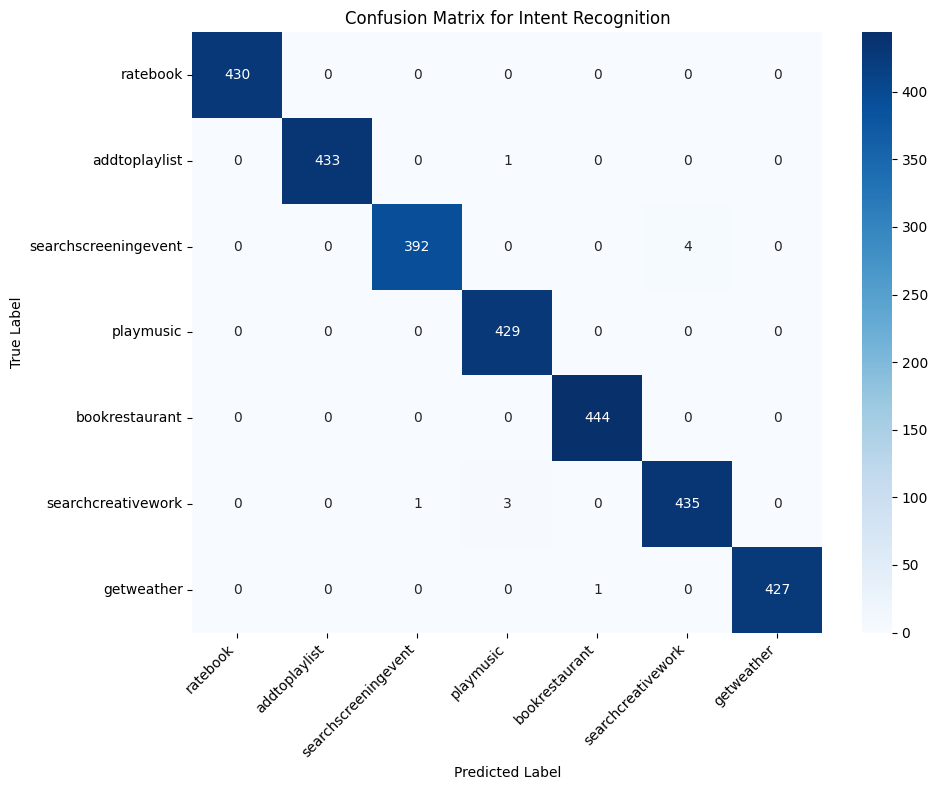

In [28]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# 1. Đánh giá mô hình trên tập dữ liệu đã có (Sử dụng biến 'dataset' thay vì 'eval_dataset' chưa được định nghĩa)
predictions, true_labels, _ = trainer.predict(dataset)

# 2. Chuyển đổi xác suất/logits dự đoán thành chỉ số nhãn có xác suất cao nhất
predicted_labels = np.argmax(predictions, axis=1)

# 3. Tạo báo cáo phân loại (Precision, Recall, F1-score cho từng nhãn)
report = classification_report(
    true_labels, predicted_labels, target_names=unique_labels
)
print("Classification Report:\n")
print(report)

# 4. Tạo ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(true_labels, predicted_labels)

# 5. Vẽ ma trận nhầm lẫn trực quan bằng Seaborn & Matplotlib
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=unique_labels,
    yticklabels=unique_labels,
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for Intent Recognition")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# save and load model

In [29]:
model.save_pretrained("fine_tuned_model")
tokenizer.save_pretrained("/finetuned_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/finetuned_model/tokenizer_config.json', '/finetuned_model/tokenizer.json')

# Prediction Sytem

In [31]:
# Load the fine-tuned model and tokenizer from the correct saved paths
model = DistilBertForSequenceClassification.from_pretrained('fine_tuned_model')
tokenizer = DistilBertTokenizer.from_pretrained('/finetuned_model')

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

In [36]:
import torch


def predict(text, model, tokenizer, max_length):
  # lower case and remove stopwords
  text = preprocess_text(text)

  # tokenize
  inputs = tokenizer(
      text,
      padding="max_length",
      truncation=True,
      max_length=max_length,
      return_tensors="pt",
  )

  # Chuyển inputs sang cùng device với model (GPU hoặc CPU)
  device = next(model.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  # Tắt tính toán gradient khi suy luận
  model.eval()
  with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits  # Sửa 'Logits = output.logits' thành 'logits = outputs.logits'

  predicted_label = torch.argmax(
      logits, dim=1
  ).item()  # Sửa 'logit' thành 'logits'
  return predicted_label  # Sửa 'predicted_labels' thành 'predicted_label'

In [40]:
# Danh sách các câu mẫu để test nhanh
test_sentences = [
    "Play my favorite upbeat songs",
    "Will it rain tomorrow in New York?",
    "Reserve a table for four at an Italian restaurant",
    "Add this song to my workout playlist",
    "Give this novel four out of five stars",
    "Find showtimes for the new action movie nearby",
    "Who is the author of this fantasy book?",
]

# Định nghĩa lại từ điển nhãn và bảng tra cứu ngược (nếu chưa chạy ở trên)
classes = {
    "ratebook": 0,
    "getweather": 1,
    "bookrestaurant": 2,
    "searchscreeningevent": 3,
    "addtoplaylist": 4,
    "searchcreativework": 5,
    "playmusic": 6,
}
idx_to_class = {v: k for k, v in classes.items()}

# Vòng lặp test từng câu
print("--- KẾT QUẢ DỰ ĐOÁN MẪU ---")
for text in test_sentences:
  intent_idx = predict(text, model, tokenizer, max_length=128)
  predicted_intent = idx_to_class[intent_idx]
  print(f"Text: '{text}'")
  print(
      f" -> Predicted Intent: {predicted_intent} (ID: {intent_idx})"
  )
  print("-" * 40)

--- KẾT QUẢ DỰ ĐOÁN MẪU ---
Text: 'Play my favorite upbeat songs'
 -> Predicted Intent: searchscreeningevent (ID: 3)
----------------------------------------
Text: 'Will it rain tomorrow in New York?'
 -> Predicted Intent: playmusic (ID: 6)
----------------------------------------
Text: 'Reserve a table for four at an Italian restaurant'
 -> Predicted Intent: addtoplaylist (ID: 4)
----------------------------------------
Text: 'Add this song to my workout playlist'
 -> Predicted Intent: getweather (ID: 1)
----------------------------------------
Text: 'Give this novel four out of five stars'
 -> Predicted Intent: ratebook (ID: 0)
----------------------------------------
Text: 'Find showtimes for the new action movie nearby'
 -> Predicted Intent: bookrestaurant (ID: 2)
----------------------------------------
Text: 'Who is the author of this fantasy book?'
 -> Predicted Intent: searchcreativework (ID: 5)
----------------------------------------


# download to local

In [ ]:
import shutil

# Path to save the model
model_dir = "/content/saved_fine_tuned_model"
model.save_pretrained(model_dir)  # Save the model
tokenizer.save_pretrained(model_dir)  # Save the tokenizer

# Zip the model folder
shutil.make_archive("distilbert_model", "zip", model_dir)

# Download the zipped model
from google.colab import files

files.download("distilbert_model.zip")

In [44]:
import os
import shutil
import kagglehub
import pandas as pd
import torch
import numpy as np
from datasets import Dataset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. TẢI VÀ CHUẨN BỊ DỮ LIỆU
# ==========================================
path = kagglehub.dataset_download("himanshunayal/intent-recognition-dataset")
files = os.listdir(path)
print("📄 Danh sách file:", files)

# Đọc các file train, valid, test
train = pd.read_csv(os.path.join(path, 'train.csv'))
val = pd.read_csv(os.path.join(path, 'valid.csv'))
test = pd.read_csv(os.path.join(path, 'test.csv'))

# Lấy 3000 mẫu để train (hoặc bạn có thể tăng lên nếu muốn)
df = train.sample(n=3000, random_state=42).reset_index(drop=True)

# Chuẩn hóa cột intent về chữ thường
df['intent'] = df['intent'].str.lower()

# ==========================================
# 2. MÃ HÓA NHÃN CHUẨN XÁC (QUAN TRỌNG)
# ==========================================
unique_labels = df['intent'].unique()

# Tạo từ điển ánh xạ từ Tên Nhãn sang Số ID và ngược lại
label_to_id = {label: i for i, label in enumerate(unique_labels)}
id_to_label = {i: label for label, i in label_to_id.items()}

print("Label to ID:", label_to_id)

# Map sang cột Label số nguyên
df['Label'] = df['intent'].map(label_to_id)

# ==========================================
# 3. TOKENIZATION
# ==========================================
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

# Tính max_length tự động dựa trên dữ liệu thực tế
max_length = max([len(tokenizer.encode(text)) for text in df['text']])
print("Max length token:", max_length)

def tokenization_function(example):
    tokenized_input = tokenizer(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=max_length
    )
    tokenized_input['labels'] = example['Label']
    return tokenized_input

# Chuyển đổi sang Hugging Face Dataset và chia train/eval (80% train, 20% eval)
dataset = Dataset.from_pandas(df[['text', 'Label']])
split_dataset = dataset.train_test_split(test_size=0.2, seed=42)

train_dataset = split_dataset['train'].map(tokenization_function, batched=True)
eval_dataset = split_dataset['test'].map(tokenization_function, batched=True)

# ==========================================
# 4. KHỞI TẠO MÔ HÌNH VÀ HUẤN LUYỆN (TRAINING)
# ==========================================
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=len(unique_labels)
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

training_args = TrainingArguments(
    output_dir='./results',
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=64,
    weight_decay=0.01,
    load_best_model_at_end=True,
)

# Trainer setup (Đã loại bỏ tham số tokenizer gây lỗi)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
)

# Bắt đầu Train
trainer.train()

# ==========================================
# 5. ĐÁNH GIÁ (EVALUATION)
# ==========================================
predictions, true_labels, _ = trainer.predict(eval_dataset)
predicted_labels = np.argmax(predictions, axis=1)

print("Classification Report:\n")
print(classification_report(true_labels, predicted_labels, target_names=unique_labels))

# ==========================================
# 6. HÀM PREDICT VÀ TEST THỰC TẾ
# ==========================================
def predict(text, model, tokenizer, max_length):
    # Tokenize trực tiếp câu thô (không loại bỏ stopwords để giữ nguyên ngữ cảnh cho BERT)
    inputs = tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=max_length,
        return_tensors='pt'
    )

    device = next(model.parameters()).device
    inputs = {k: v.to(device) for k, v in inputs.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**inputs)
        logits = outputs.logits

    predicted_label_idx = torch.argmax(logits, dim=1).item()
    return predicted_label_idx

# Danh sách câu mẫu test
test_sentences = [
    "Play my favorite upbeat songs",
    "Will it rain tomorrow in New York?",
    "Reserve a table for four at an Italian restaurant",
    "Add this song to my workout playlist",
    "Give this novel four out of five stars",
    "Find showtimes for the new action movie nearby",
    "Who is the author of this fantasy book?"
]

print("\n--- KẾT QUẢ DỰ ĐOÁN SAU KHI SỬA ---")
for text in test_sentences:
    intent_idx = predict(text, model, tokenizer, max_length)
    # Dùng đúng từ điển ánh xạ ngược id_to_label sinh ra từ quá trình train
    predicted_intent = id_to_label[intent_idx]
    print(f"Text: '{text}'")
    print(f" -> Predicted Intent: {predicted_intent} (ID: {intent_idx})")
    print("-" * 40)

Using Colab cache for faster access to the 'intent-recognition-dataset' dataset.
📄 Danh sách file: ['valid.csv', 'train.csv', 'test.csv']
Label to ID: {'ratebook': 0, 'playmusic': 1, 'bookrestaurant': 2, 'getweather': 3, 'searchscreeningevent': 4, 'addtoplaylist': 5, 'searchcreativework': 6}
Max length token: 34


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/600 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,No log,0.138413
2,No log,0.073925
3,No log,0.069722


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Classification Report:

                      precision    recall  f1-score   support

            ratebook       1.00      1.00      1.00        82
           playmusic       0.98      0.98      0.98        91
      bookrestaurant       1.00      1.00      1.00        92
          getweather       1.00      1.00      1.00        85
searchscreeningevent       0.95      0.98      0.96        90
       addtoplaylist       1.00      0.99      0.99        77
  searchcreativework       0.95      0.93      0.94        83

            accuracy                           0.98       600
           macro avg       0.98      0.98      0.98       600
        weighted avg       0.98      0.98      0.98       600


--- KẾT QUẢ DỰ ĐOÁN SAU KHI SỬA ---
Text: 'Play my favorite upbeat songs'
 -> Predicted Intent: playmusic (ID: 1)
----------------------------------------
Text: 'Will it rain tomorrow in New York?'
 -> Predicted Intent: getweather (ID: 3)
----------------------------------------
Text: 'Res

# Gradio visuzlize

In [45]:
import gradio as gr
import torch
import torch.nn.functional as F


def predict_intent_ui(text):
  if not text.strip():
    return "Vui lòng nhập một câu lệnh hợp lệ!", "{}"

  # Tokenize văn bản
  inputs = tokenizer(
      text,
      padding="max_length",
      truncation=True,
      max_length=max_length,
      return_tensors="pt",
  )

  device = next(model.parameters()).device
  inputs = {k: v.to(device) for k, v in inputs.items()}

  model.eval()
  with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits

  # Tính xác suất (Softmax) cho từng nhãn
  probabilities = F.softmax(logits, dim=1)[0]
  predicted_idx = torch.argmax(logits, dim=1).item()

  # Lấy tên ý định dự đoán tốt nhất
  predicted_intent = id_to_label[predicted_idx]

  # Tạo từ điển chứa độ tin cậy của tất cả các nhãn để hiển thị bảng/dict
  all_scores = {
      id_to_label[i]: float(probabilities[i].item())
      for i in range(len(unique_labels))
  }
  # Sắp xếp theo độ tin cậy giảm dần
  sorted_scores = dict(
      sorted(all_scores.items(), key=lambda item: item[1], reverse=True)
  )

  return (
      f"🎯 Ý định dự đoán: {predicted_intent.upper()} (ID: {predicted_idx})",
      sorted_scores,
  )


# Thiết kế giao diện Gradio hiện đại (Blocks API)
with gr.Blocks(theme=gr.themes.Soft()) as demo:
  gr.Markdown(
      "# 🤖 Trợ Lý Nhận Diện Ý Định (Intent Recognition - DistilBERT)"
  )
  gr.Markdown(
      "Nhập câu lệnh của bạn bên dưới hoặc chọn các câu mẫu có sẵn để kiểm"
      " tra mô hình."
  )

  with gr.Row():
    with gr.Column(scale=2):
      input_text = gr.Textbox(
          label="Nhập câu lệnh:",
          placeholder="Ví dụ: Play my favorite upbeat songs...",
          lines=3,
      )

      with gr.Row():
        clear_btn = gr.Button("Xóa")
        submit_btn = gr.Button("Dự Đoán", variant="primary")

      gr.Markdown("### 💡 Câu mẫu gợi ý:")
      gr.Examples(
          examples=[
              "Play my favorite upbeat songs",
              "Will it rain tomorrow in New York?",
              "Reserve a table for four at an Italian restaurant",
              "Add this song to my workout playlist",
              "Give this novel four out of five stars",
              "Find showtimes for the new action movie nearby",
              "Who is the author of this fantasy book?",
          ],
          inputs=input_text,
      )

    with gr.Column(scale=2):
      output_label = gr.Markdown(label="Kết quả chính")
      output_json = gr.Label(
          label="Độ tin cậy của các Intent (Confidence Scores)"
      )

  # Gắn sự kiện khi bấm nút hoặc nhấn Enter
  submit_btn.click(
      fn=predict_intent_ui,
      inputs=input_text,
      outputs=[output_label, output_json],
  )
  input_text.submit(
      fn=predict_intent_ui,
      inputs=input_text,
      outputs=[output_label, output_json],
  )
  clear_btn.click(fn=lambda: ("", {}), outputs=[input_text, output_json])

# Chạy giao diện trên Colab (hỗ trợ share=True để tạo link công khai tạm thời)
demo.launch(inline=False, share=True)

/tmp/ipykernel_395/3105240404.py:51: UserWarning: The parameters have been moved from the Blocks constructor to the launch() method in Gradio 6.0: theme. Please pass these parameters to launch() instead.
  with gr.Blocks(theme=gr.themes.Soft()) as demo:


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b0984584d5fad6d434.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# push to HUGGINFACE

In [ ]:
!pip install huggingface_hub

In [46]:
from huggingface_hub import HfApi, login

# 1. Đăng nhập vào Hugging Face (Chạy cell này nó sẽ hiện ô nhập token)
print("🔑 Vui lòng nhập Hugging Face Write Token của bạn bên dưới:")
login()

# 2. Đặt tên repository bạn muốn hiển thị trên Hugging Face
# Ví dụ: "username-cua-ban/distilbert-intent-recognition"
repo_id = (
    "phong8901/distilbert-intent-recognition"  # <-- Thay bằng username và tên repo của bạn
)

print(
    f"🚀 Đang đẩy mô hình lên kho lưu trữ Hugging Face Hub: {repo_id} ..."
)

# 3. Push mô hình và tokenizer trực tiếp từ đối tượng đang có trong RAM lên Hub
model.push_to_hub(repo_id, private=False)  # private=True nếu bạn muốn để chế độ riêng tư
tokenizer.push_to_hub(repo_id, private=False)

print(f"✅ Đẩy mô hình thành công! Bạn có thể xem tại: https://huggingface.co/{repo_id}")

🔑 Vui lòng nhập Hugging Face Write Token của bạn bên dưới:
🚀 Đang đẩy mô hình lên kho lưu trữ Hugging Face Hub: phong8901/distilbert-intent-recognition ...


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...g26t1os/model.safetensors:   0%|          |  575kB /  268MB            

Validating                    :           |   0%            

README.md:   0%|          | 0.00/5.17k [00:00<?, ?B/s]

✅ Đẩy mô hình thành công! Bạn có thể xem tại: https://huggingface.co/phong8901/distilbert-intent-recognition
